In [1]:
import sys
import torch
import random
import time
from models import *
from utils import *
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from torch.utils.data.sampler import SubsetRandomSampler
import os
import logging
logging.basicConfig(filename='./logs/daf.log', level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

In [3]:
def set_seed(seed_value=973028):
    """Set seed for reproducibility."""
    random.seed(seed_value)  # Python random module
    np.random.seed(seed_value)  # Numpy module
    torch.manual_seed(seed_value)  # PyTorch
    os.environ['PYTHONHASHSEED'] = str(seed_value)  # Python hash seed
    
    # CUDA reproducibility
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)  # if use multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [5]:
class Generator(nn.Module):
    def __init__(self, input_nc, output_nc, init_depth, s_depth, bc=True, n_residual_blocks=9, domains=2, log=True):
        super(Generator, self).__init__()

        self.z_size = 17 if bc else 7
        #### encode
        ec = [   nn.ReflectionPad2d(3),
                    nn.Conv2d(input_nc, init_depth, 7),
                    nn.InstanceNorm2d(init_depth),
                    nn.ReLU(inplace=True) ]

        # Downsampling
        ec += [  nn.Conv2d(init_depth, init_depth*2, 3, stride=2, padding=1),
                 nn.InstanceNorm2d(init_depth*2),
                 nn.ReLU(inplace=True) ]
        
        ec += [  nn.Conv2d(init_depth*2, init_depth*4-s_depth, 3, stride=2, padding=1),
                 nn.InstanceNorm2d(init_depth*4-s_depth),
                 nn.ReLU(inplace=True) ]
        in_features = init_depth*4-s_depth
        
        # Residual blocks
        for _ in range(n_residual_blocks):
            ec += [ResidualBlock(in_features)]
        
        #### encode
        self.ec = nn.Sequential(*ec)
        # Embed layer
        self.s_depth = s_depth
        self.embed = nn.Embedding(domains, self.z_size*self.z_size*s_depth)
        self.z1 = nn.Conv2d(in_features, int((in_features + s_depth)/2), 5, stride=4)
        self.tconv1 = nn.ConvTranspose2d(int((in_features + s_depth)/2), int((in_features + s_depth)/2), kernel_size=5, stride=4, padding=1, output_padding=2)
        self.tconv2 = nn.ConvTranspose2d(int((in_features + s_depth)/2), in_features, kernel_size=1, stride=1)
        
        #### decode
        in_features = init_depth*4
        dc = []            
        # Upsampling
        out_features = in_features//2
        for _ in range(2):
            dc += [  nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                     nn.InstanceNorm2d(out_features),
                     nn.ReLU(inplace=True) ]
            in_features = out_features
            out_features = in_features//2
        
        # # Output layer
        # if log:
        #     dc += [  nn.ReflectionPad2d(3),
        #              nn.Conv2d(init_depth, output_nc, 7),
        #              nn.ReLU()]
        # else:
        #     dc += [  nn.ReflectionPad2d(3),
        #              nn.Conv2d(init_depth, output_nc, 7),
        #              nn.Tanh() ]
        #### decode
        self.dc = nn.Sequential(*dc)
        
        # Dual-heads: mask and value
        self.mask_head = nn.Conv2d(in_features, 1, kernel_size=1)
        self.val_head  = nn.Conv2d(in_features, 1, kernel_size=1)
        
        self.log = log
        
    def forward(self, x, s):
        x = self.ec(x)
        x = self.z1(x)
        z = x.view(x.shape[0], -1)
        x = self.tconv2(self.tconv1(x))
        ##
        s_x = self.embed(s).view(x.shape[0], self.s_depth, self.z_size, self.z_size)
        xs = torch.cat((x,s_x),dim=1)
        
        # Decode backbone
        pre = self.dc(xs)
        # Heads
        mask_logit = self.mask_head(pre)
        val_log    = self.val_head(pre)
        # Probability mask
        P = torch.sigmoid(mask_logit)
        # Value to rate
        rate = torch.exp(val_log) if self.log else F.softplus(val_log)
        # Combined adjacency
        Ahat = P * rate
        # Enforce symmetry and zero diag
        Ahat = 0.5 * (Ahat + Ahat.transpose(-1, -2))
        eye = torch.eye(Ahat.size(-1), device=Ahat.device)
        Ahat = Ahat * (1 - eye)
        return Ahat, z
    

# Unsupervised DAF

## Load brain connectome data

(adjacency matrices)

In [4]:
dat_abcd = loadmat('../abcd/new_abcd_cog.mat')
dat_hcp = loadmat('../hcp/HCP_subcortical_CMData_desikan.mat')
tensor_abcd = dat_abcd['count_network']
tensor_hcp = dat_hcp['loaded_tensor_sub']

In [5]:
# whether to apply log transformation to the adjacency matrices)
log=True

In [6]:
set_seed(1972014)
# np.random.seed(123456)
# orders = np.random.permutation(np.arange(68))
# offset = 18994
net_abcd = []
for i in range(tensor_abcd.shape[2]):
    ith = np.float32(tensor_abcd[:,:,i])
    if log:
        ith = np.log(ith+1)
    ith = ith.reshape(68*68)
    net_abcd.append(ith)
n_abcd = len(net_abcd)

net_hcp = []
for i in range(tensor_hcp.shape[3]):
    ith = np.float32(tensor_hcp[:,:,0,i] + np.transpose(tensor_hcp[:,:,0,i]))
    ith = ith[18:86, 18:86]
    if log:
        ith = np.log(ith+1)
#     np.fill_diagonal(ith,np.mean(ith, 0))
    ith = ith.reshape(68*68)
    net_hcp.append(ith)
n_hcp = len(net_hcp)

For similicity, sample from ABCD and HCP

In [7]:
_, id_abcd = train_test_split(range(n_abcd), test_size=892/n_abcd, random_state=42) # big 5079, small 173
_, id_hcp = train_test_split(range(n_hcp), test_size=173/n_hcp, random_state=42) # big 5079, small 173

print('abcd',len(id_abcd))
print('hcp',len(id_hcp))

abcd 892
hcp 173


In [8]:
net_abcd = [net_abcd[i] for i in id_abcd]
net_hcp = [net_hcp[i] for i in id_hcp]
net_all = net_abcd + net_hcp

## preprocess

In [9]:
if log:
    net_all = torch.stack([torch.Tensor(i) for i in net_all]).view(-1,1,68,68)
else:
    # If no log transformation, scale data to range [0,1] (default in cycle gan)
    offset = np.max(net_all)/2 # 9497
    net_all = torch.stack([torch.Tensor((i-offset)/offset) for i in net_all]).view(-1,1,68,68)

n_abcd, n_hcp = len(id_abcd), len(id_hcp)
n = n_abcd + n_hcp
# domain label: ABCD(0) HCP(1)
labels = torch.cat((torch.tensor([0]).expand(n_abcd,1), torch.tensor([1]).expand(n_hcp,1)))

## Data loader

In [10]:
set_seed(1972034)
nepoch = 300
dataset = utils.TensorDataset(net_all, labels)
# split train and validataion 
train_id, test_id = train_test_split(list(range(n)),train_size=0.9, random_state=42)
train_dataset = utils.Subset(dataset, train_id)
test_dataset = utils.Subset(dataset, test_id)
train_loader = utils.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = utils.DataLoader(test_dataset, batch_size=len(test_id), shuffle=False)

## DAF model configuration

In [11]:
# Networks
set_seed(1972014)
netG_A2B = Generator(input_nc=1, output_nc=1, init_depth=48, s_depth=10, n_residual_blocks=5).to(device)
netG_B2A = Generator(input_nc=1, output_nc=1, init_depth=48, s_depth=10, n_residual_blocks=5).to(device)
netD_A = Discriminator(input_nc=1, init_depth=48).to(device)
netD_B = Discriminator(input_nc=1, init_depth=48).to(device)

# Lossess
criterion_GAN = torch.nn.MSELoss()
criterion_cycle = torch.nn.L1Loss()

# Optimizers & LR schedulers
optimizer_G = torch.optim.Adam(itertools.chain(netG_A2B.parameters(), netG_B2A.parameters()),
                                lr=0.0002, betas=(0.5, 0.999))
optimizer_D_A = torch.optim.Adam(netD_A.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D_B = torch.optim.Adam(netD_B.parameters(), lr=0.0002, betas=(0.5, 0.999))

lr_scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda=LambdaLR(nepoch, 0, nepoch/2).step)
lr_scheduler_D_A = torch.optim.lr_scheduler.LambdaLR(optimizer_D_A, lr_lambda=LambdaLR(nepoch, 0, nepoch/2).step)
lr_scheduler_D_B = torch.optim.lr_scheduler.LambdaLR(optimizer_D_B, lr_lambda=LambdaLR(nepoch, 0, nepoch/2).step)



## Train

In [23]:
train_G_loss=[]
test_G_loss=[]
train_DA_loss=[]
test_DA_loss=[]
train_DB_loss=[]
test_DB_loss=[]
# frequency to monitor test loss
evaluate_every = 1

for epoch in range(0, nepoch):
    
    G_losses=[]
    DA_losses=[]
    DB_losses=[]
    iden=[]
    gan=[]
    cyc=[]
    dep=[]

    tic = time.perf_counter()
    for i, (A, s) in enumerate(train_loader):
        
        # Set model input
        real_A = A.to(device)
        real_B = A.to(device)
        s = s.to(device)
        bs = real_A.shape[0]
        
        # Inputs & targets memory allocation
        Tensor = torch.FloatTensor
        target_real = Variable(Tensor(bs,1).fill_(1.0), requires_grad=False).to(device)
        target_fake = Variable(Tensor(bs,1).fill_(0.0), requires_grad=False).to(device)
        
        ###### Generators A2B and B2A ######
        optimizer_G.zero_grad()
        
        # GAN loss 
        fake_B, _ = netG_A2B(real_A, s)
        pred_fake = netD_B(fake_B)
        loss_GAN_A2B = criterion_GAN(pred_fake, target_real)
        
        fake_A, _ = netG_B2A(real_B, s)
        pred_fake = netD_A(fake_A)
        loss_GAN_B2A = criterion_GAN(pred_fake, target_real)
        
        # Cycle loss
        recovered_A, _ = netG_B2A(fake_B, s)
        loss_cycle_ABA = criterion_cycle(recovered_A, real_A)*10.0

        recovered_B, _ = netG_A2B(fake_A, s)
        loss_cycle_BAB = criterion_cycle(recovered_B, real_B)*10.0
        
        # Dependence loss
        xt = fake_B.view(bs, -1)
        s = s.view(bs, 1)
        DLR = dependence(xt, s, sig=20, device=device) 

        loss_G = loss_GAN_A2B + loss_GAN_B2A + loss_cycle_ABA + loss_cycle_BAB + DLR   #+ loss_pred#if feed_iden else loss_GAN_A2B + loss_GAN_B2A + loss_cycle_ABA + loss_cycle_BAB
        loss_G.backward()
        
        optimizer_G.step()
        ###################################

        ###### Discriminator A ######
        optimizer_D_A.zero_grad()

        # Real loss
        pred_real = netD_A(real_A)
        loss_D_real = criterion_GAN(pred_real, target_real)

        # Fake loss
        pred_fake = netD_A(fake_A.detach())
        loss_D_fake = criterion_GAN(pred_fake, target_fake)

        # Total loss
        loss_D_A = (loss_D_real + loss_D_fake)*0.5
        loss_D_A.backward()

        optimizer_D_A.step()
        ###################################

        ###### Discriminator B ######
        optimizer_D_B.zero_grad()

        # Real loss
        pred_real = netD_B(real_B)
        loss_D_real = criterion_GAN(pred_real, target_real)
        
        # Fake loss
        pred_fake = netD_B(fake_B.detach())
        loss_D_fake = criterion_GAN(pred_fake, target_fake)

        # Total loss
        loss_D_B = (loss_D_real + loss_D_fake)*0.5
        loss_D_B.backward()

        optimizer_D_B.step()
        ###################################
        
        # collect loss
        G_losses.append(loss_G.data.item())
        DA_losses.append(loss_D_A.data.item())
        DB_losses.append(loss_D_B.data.item())
        ####
        gan.append(loss_GAN_A2B.data.item() + loss_GAN_B2A.data.item())
        cyc.append(loss_cycle_ABA.data.item() + loss_cycle_BAB.data.item())
        dep.append(DLR.data.item())
        
    # Update learning rates
    lr_scheduler_G.step()
    lr_scheduler_D_A.step()
    lr_scheduler_D_B.step()
    
    G_loss_epoch =  torch.mean(torch.FloatTensor(G_losses))
    DA_loss_epoch =  torch.mean(torch.FloatTensor(DA_losses))
    DB_loss_epoch =  torch.mean(torch.FloatTensor(DB_losses))
    #####
    gan_epoch =  torch.mean(torch.FloatTensor(gan))
    cyc_epoch =  torch.mean(torch.FloatTensor(cyc))
    dep_epoch =  torch.mean(torch.FloatTensor(dep))
    toc = time.perf_counter()
    print(f"trained epoch in {toc - tic:0.4f} seconds") 
    
    if (epoch + 1) % evaluate_every == 0:
        G_loss_test, DA_loss_test, DB_loss_test, gan_test, cyc_test, dep_test = evaluate(netG_A2B, netG_B2A, netD_A, netD_B, 
                                                                                         test_loader, epoch, device, save = True, plot=True,
                                                                                         root='./saved_model/unsup_daf/')
    
    logging.info('-'*15+'train loss'+'-'*15)    
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, loss_D_A: {DA_loss_epoch:.3f}, loss_D_B: {DB_loss_epoch:.3f}, loss_G: {G_loss_epoch:.3f}")
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, loss_gan: {gan_epoch:.3f}, loss_cyc: {cyc_epoch:.3f}, loss_dep: {dep_epoch:.3f}")
    logging.info('-'*15+' test loss'+'-'*15)   
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, loss_D_A: {DA_loss_test:.3f}, loss_D_B: {DB_loss_test:.3f}, loss_G: {G_loss_test:.3f}")
    logging.info(f"Epoch: {epoch + 1}/{nepoch}, loss_gan: {gan_test:.3f}, loss_cyc: {cyc_test:.3f}, loss_dep: {dep_test:.3f}")
    logging.info('*'*40)

    print('-'*15+'train loss'+'-'*15)    
    print(f"Epoch: {epoch + 1}/{nepoch}, loss_D_A: {DA_loss_epoch:.3f}, loss_D_B: {DB_loss_epoch:.3f}, loss_G: {G_loss_epoch:.3f}")
    print(f"Epoch: {epoch + 1}/{nepoch}, loss_gan: {gan_epoch:.3f}, loss_cyc: {cyc_epoch:.3f}, loss_dep: {dep_epoch:.3f}")
    print('-'*15+' test loss'+'-'*15)   
    print(f"Epoch: {epoch + 1}/{nepoch}, loss_D_A: {DA_loss_test:.3f}, loss_D_B: {DB_loss_test:.3f}, loss_G: {G_loss_test:.3f}")
    print(f"Epoch: {epoch + 1}/{nepoch}, loss_gan: {gan_test:.3f}, loss_cyc: {cyc_test:.3f}, loss_dep: {dep_test:.3f}")
    print('*'*40)
    
    train_G_loss.append(G_loss_epoch.item())
    test_G_loss.append(G_loss_test)
    train_DA_loss.append(DA_loss_epoch.item())
    test_DA_loss.append(DA_loss_test)
    train_DB_loss.append(DB_loss_epoch.item())
    test_DB_loss.append(DB_loss_test)

    

trained epoch in 2.9293 seconds
---------------train loss---------------
Epoch: 1/300, loss_D_A: 0.116, loss_D_B: 0.108, loss_G: 37.237
Epoch: 1/300, loss_gan: 1.543, loss_cyc: 35.667, loss_dep: 0.027
--------------- test loss---------------
Epoch: 1/300, loss_D_A: 0.013, loss_D_B: 0.050, loss_G: 35.758
Epoch: 1/300, loss_gan: 1.347, loss_cyc: 34.408, loss_dep: 0.003
****************************************
trained epoch in 1.8238 seconds
---------------train loss---------------
Epoch: 2/300, loss_D_A: 0.046, loss_D_B: 0.014, loss_G: 36.276
Epoch: 2/300, loss_gan: 1.932, loss_cyc: 34.340, loss_dep: 0.004
--------------- test loss---------------
Epoch: 2/300, loss_D_A: 0.046, loss_D_B: 0.003, loss_G: 35.388
Epoch: 2/300, loss_gan: 1.448, loss_cyc: 33.924, loss_dep: 0.016
****************************************
trained epoch in 1.7594 seconds
---------------train loss---------------
Epoch: 3/300, loss_D_A: 0.033, loss_D_B: 0.079, loss_G: 34.768
Epoch: 3/300, loss_gan: 1.649, loss_cyc: 3

In [51]:
a1 = netG_A2B(torch.tensor(net_abcd[0]).view(1,1,68,68).to(device), torch.zeros(1).long().to(device))[0]
(a1[0,0,0,:]<0.1).sum()

tensor(43, device='cuda:1')

In [44]:
class Generator(nn.Module):
    def __init__(self, input_nc, output_nc, init_depth, s_depth, bc=True, n_residual_blocks=9, domains=2, log=True):
        super(Generator, self).__init__()

        self.z_size = 17 if bc else 7
        #### encode
        ec = [   nn.ReflectionPad2d(3),
                    nn.Conv2d(input_nc, init_depth, 7),
                    nn.InstanceNorm2d(init_depth),
                    nn.ReLU(inplace=True) ]

        # Downsampling
        ec += [  nn.Conv2d(init_depth, init_depth*2, 3, stride=2, padding=1),
                 nn.InstanceNorm2d(init_depth*2),
                 nn.ReLU(inplace=True) ]
        
        ec += [  nn.Conv2d(init_depth*2, init_depth*4-s_depth, 3, stride=2, padding=1),
                 nn.InstanceNorm2d(init_depth*4-s_depth),
                 nn.ReLU(inplace=True) ]
        in_features = init_depth*4-s_depth
        
        # Residual blocks
        for _ in range(n_residual_blocks):
            ec += [ResidualBlock(in_features)]
        
        #### encode
        self.ec = nn.Sequential(*ec)
        # Embed layer
        self.s_depth = s_depth
        self.embed = nn.Embedding(domains, self.z_size*self.z_size*s_depth)
        self.z1 = nn.Conv2d(in_features, int((in_features + s_depth)/2), 5, stride=4)
        self.tconv1 = nn.ConvTranspose2d(int((in_features + s_depth)/2), int((in_features + s_depth)/2), kernel_size=5, stride=4, padding=1, output_padding=2)
        self.tconv2 = nn.ConvTranspose2d(int((in_features + s_depth)/2), in_features, kernel_size=1, stride=1)
        
        #### decode
        in_features = init_depth*4
        dc = []            
        # Upsampling
        out_features = in_features//2
        for _ in range(2):
            dc += [  nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                     nn.InstanceNorm2d(out_features),
                     nn.ReLU(inplace=True) ]
            in_features = out_features
            out_features = in_features//2

        # Output layer
        if log:
            dc += [  nn.ReflectionPad2d(3),
                     nn.Conv2d(init_depth, output_nc, 7),
                     nn.ReLU()]
        else:
            dc += [  nn.ReflectionPad2d(3),
                     nn.Conv2d(init_depth, output_nc, 7),
                     nn.Tanh() ]
        #### decode
        self.dc = nn.Sequential(*dc)
        
    def forward(self, x, s):
        x = self.ec(x)
        x = self.z1(x)
        z = x.view(x.shape[0], -1)
        x = self.tconv2(self.tconv1(x))
        ##
        s_x = self.embed(s).view(x.shape[0], self.s_depth, self.z_size, self.z_size)
        xs = torch.cat((x,s_x),dim=1)
        xt = self.dc(xs)
        return xt, z
netG_A2B_vanilla = Generator(input_nc=1,output_nc=1,
                     init_depth=48,s_depth=10,
                     bc=True,
                     n_residual_blocks=5,domains=2).to(device)
netG_A2B_vanilla.load_state_dict(torch.load("saved_model/unsup_daf/G_A2B.pth"))

<All keys matched successfully>

In [46]:
a0=netG_A2B_vanilla(torch.tensor(net_abcd[0]).view(1,1,68,68).to(device), torch.zeros(1).long().to(device))[0]

In [50]:
(a0[0,0,0,:]<0.1).sum()

tensor(49, device='cuda:1')

In [35]:
torch.set_printoptions(sci_mode=False)
fake_B[0,0]

tensor([[    0.0000,     0.0162,     2.4736,  ...,     0.0033,     0.0011,
             0.0094],
        [    0.0162,     0.0000,     6.7850,  ...,     0.0022,     0.0026,
             0.6421],
        [    2.4736,     6.7850,     0.0000,  ...,     0.0032,     0.0009,
             1.2507],
        ...,
        [    0.0033,     0.0022,     0.0032,  ...,     0.0000,     0.0049,
             6.5216],
        [    0.0011,     0.0026,     0.0009,  ...,     0.0049,     0.0000,
             7.1140],
        [    0.0094,     0.6421,     1.2507,  ...,     6.5216,     7.1140,
             0.0000]], device='cuda:1', grad_fn=<SelectBackward0>)

Note: specify `plot=True` in `evaluate` to monitor the visualized generated and reconstructed data. Figures are saved in `saved_model/unsup_daf/figs/`.

Figures are 3x6 grid. 

Row 1: observed, row 2: generated, row 3: reconstructed

Column 1-3: ABCD matrices. Column 4-6: HCP matrices.

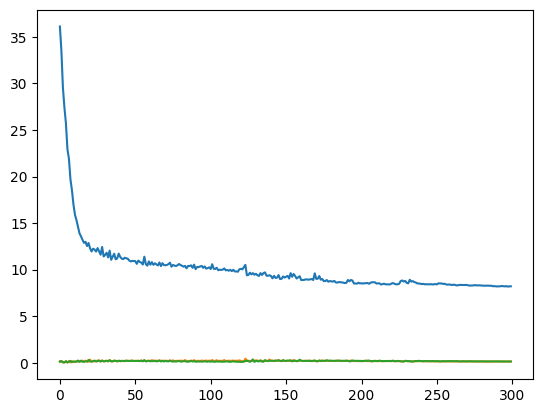

In [13]:
plt.plot(range(nepoch),train_G_loss)
plt.plot(range(nepoch),train_DA_loss)
plt.plot(range(nepoch),train_DB_loss)
# plt.ylim(0,3)

(0.0, 3.0)

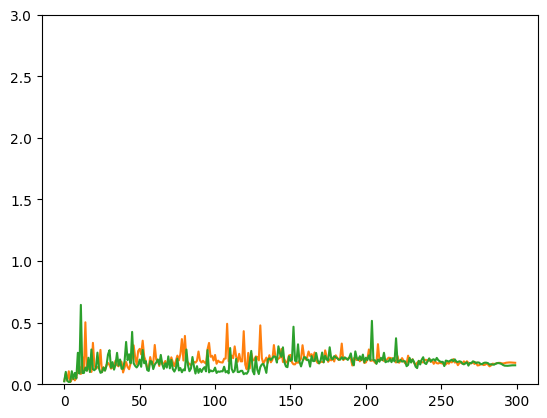

In [14]:
plt.plot(range(nepoch),test_G_loss)
plt.plot(range(nepoch),test_DA_loss)
plt.plot(range(nepoch),test_DB_loss)
plt.ylim(0,3)

# DAF regression

## Load traits

In [12]:
# Load trait data for ABCD
trait_abcd_all = dat_abcd['nih_cogn']

# Load trait data for HCP
phen_dat = loadmat('../hcp/HCP_Covariates.mat')

# Get subject IDs from both datasets
hcp_all_subject_ids = phen_dat['allsubject_id'].squeeze()  # All subjects in covariates file (1206 subjects)
hcp_connectome_subject_ids = dat_hcp['all_id'].squeeze()   # Subjects with connectome data (1065 subjects)

# Create mapping from HCP connectome subjects to their corresponding indices in the covariates file
# This finds the index in the covariates file for each subject in the connectome data
phen_idx = []
for subject_id in hcp_connectome_subject_ids:
    # Find where this subject appears in the full subject list
    idx = np.where(hcp_all_subject_ids == subject_id)[0]
    if len(idx) > 0:
        phen_idx.append(idx[0])
    else:
        # Handle case where subject not found (shouldn't happen based on our checks)
        print(f"Warning: Subject {subject_id} not found in covariates file")
        phen_idx.append(None)

# Extract only the traits for subjects that have connectome data
# This uses the mapping we created to get the right indices
trait_hcp_all = phen_dat['cog_measure'][:, phen_idx]  # shape: (num_traits, num_connectome_subjects)

# Then use the id_hcp indices which select which of the connectome subjects to use
# Note: If sample=False, id_hcp is all subjects, so this doesn't change anything
trait_hcp_all = trait_hcp_all[:, id_hcp]  # shape: (num_traits, num_selected_subjects)
trait_abcd_all = trait_abcd_all[id_abcd]  # shape: (num_selected_subjects, num_traits)

# Transpose the HCP traits to match the shape of ABCD traits (subjects x traits)
trait_hcp_all = trait_hcp_all.reshape(-1, n_hcp).transpose(1, 0)

# Handle missing values and normalize traits
col_means = np.nanmean(trait_abcd_all, axis=0)
inds = np.where(np.isnan(trait_abcd_all))
trait_abcd_all[inds] = np.take(col_means, inds[1])
means_abcd, stds_abcd = np.mean(trait_abcd_all, axis=0), np.std(trait_abcd_all, axis=0)
trait_abcd_all = (trait_abcd_all - means_abcd) / stds_abcd

col_means = np.nanmean(trait_hcp_all, axis=0)
inds = np.where(np.isnan(trait_hcp_all))
trait_hcp_all[inds] = np.take(col_means, inds[1])
means_hcp, stds_hcp = np.mean(trait_hcp_all, axis=0), np.std(trait_hcp_all, axis=0)
trait_hcp_all = (trait_hcp_all - means_hcp) / stds_hcp

# Handle specific trait if needed
trait_hcp_all[:, 137] = 0

trait_abcd_all = torch.from_numpy(trait_abcd_all)
trait_hcp_all = torch.from_numpy(trait_hcp_all)

print("HCP traits shape:", trait_hcp_all.shape)
print("ABCD traits shape:", trait_abcd_all.shape)

HCP traits shape: torch.Size([173, 175])
ABCD traits shape: torch.Size([892, 30])


/tmp/ipykernel_4109361/303806022.py:47: RuntimeWarning: invalid value encountered in divide
  trait_hcp_all = (trait_hcp_all - means_hcp) / stds_hcp


## Load trained DAF model and transform data

In [21]:
if log:
    net_abcd = torch.stack([torch.Tensor(i) for i in net_abcd]).view(-1,1,68,68)
    net_hcp = torch.stack([torch.Tensor(i) for i in net_hcp]).view(-1,1,68,68)
else:
    offset = np.max(net_s)/2 
    net_abcd = torch.stack([torch.Tensor((i-offset)/offset) for i in net_abcd]).view(-1,1,68,68)
    net_hcp = torch.stack([torch.Tensor((i-offset)/offset) for i in net_hcp]).view(-1,1,68,68)

d=48
netG_A2B = Generator(input_nc=1,output_nc=1,
                     init_depth=d,s_depth=10,
                     bc=True,
                     n_residual_blocks=5,domains=2).to(device)
netG_B2A = Generator(input_nc=1,output_nc=1,init_depth=d,s_depth=10,bc=True,n_residual_blocks=5,domains=2).to(device)
netG_A2B.load_state_dict(torch.load("saved_model/unsup_daf/G_A2B.pth"))#_e200_G8.572_gan0.778_cyc8.0_dep0.265.pth"))
netG_B2A.load_state_dict(torch.load("saved_model/unsup_daf/G_B2A.pth"))#_e200_G8.572_gan0.778_cyc8.0_dep0.265.pth"))


<All keys matched successfully>

In [22]:
with torch.no_grad():
    net1_abcd, z_abcd = netG_A2B(net_abcd.to(device), torch.tensor([0]).expand(n_abcd, 1).to(device))
    netr_abcd, z1_abcd = netG_B2A(net1_abcd.to(device), torch.tensor([0]).expand(n_abcd, 1).to(device))

    net1_hcp, z_hcp = netG_A2B(net_hcp.to(device), torch.tensor([1]).expand(n_hcp, 1).to(device))
    netr_hcp, z1_hcp = netG_B2A(net1_hcp.to(device), torch.tensor([1]).expand(n_hcp, 1).to(device))

    net1_abcd, z_abcd, z1_abcd = net1_abcd.cpu().view(-1, 68*68), z_abcd.cpu(), z1_abcd.cpu()
    net1_hcp, z_hcp, z1_hcp = net1_hcp.cpu().view(-1, 68*68), z_hcp.cpu(), z1_hcp.cpu()

torch.cuda.empty_cache()

In [15]:
# z1_hcp = torch.cat((z_hcp,z1_hcp),1)
z1_hcp = z_hcp

## MLP

In [23]:
# metric: coefficient of determination (R^2)
def coefod(yhat,y):
    return 1-(((y-yhat)**2).sum()/((y-y.mean())**2).sum())

In [24]:
def evaluate_MLP(model, x, y, epoch, save=False, root=None):
    model.eval()
    with torch.no_grad():
        x = x.to(device)
        yhat = model(x)
        yhat = yhat.detach().cpu().view(-1)

        loss = F.mse_loss(yhat, y, reduction="mean").item()
        corr = np.corrcoef(yhat,y)[0,1].item()
        cod = coefod(yhat, y).item()
    if save:
        if not os.path.exists(root):
            # Create the directory
            os.makedirs(root)
            print(f"Directory '{root}' was created.")
        torch.save(model.state_dict(), root+'e'+str(epoch)+'.pth')
    return loss, corr, cod

In [25]:
traits = [24] # trait index

In [26]:
# repetitions: in each repetition, randomly divide HCP dataset into K-shot (training) set and remaining (testing) set
rep = 30
num_traits = len(traits)
cor_reps = torch.zeros([rep, num_traits])
mse_reps = torch.zeros([rep, num_traits])
cod_reps = torch.zeros([rep, num_traits])
set_seed()

for t in range(len(traits)):

    trait_id = traits[t]
    trait_hcp = trait_hcp_all[:,trait_id].float()
    trait_abcd = trait_abcd_all.float()
    loss_test_list = torch.zeros(rep)
    corr_test_list = torch.zeros(rep)
    cod_test_list = torch.zeros(rep)
    random.seed(1972014)
    r = 0
    count = 0
    redo = False
    # while r < rep: #and count <= 100:
    for r in range(rep):
        id_kshot = random.sample(range(n_hcp), 50)
        id_remain = [ele for ele in list(range(n_hcp)) if ele not in id_kshot]

        trait_remain = trait_hcp[id_remain]
        n_kshot, n_remain = len(id_kshot), len(id_remain)

        print('%%%%%% Train on K-shot set')

        id_kshot_train, id_kshot_val = train_test_split(id_kshot, test_size=0.1, random_state=42)
        train_dataset = utils.TensorDataset(z1_hcp[id_kshot_train], trait_hcp[id_kshot_train])
        train_loader = utils.DataLoader(train_dataset, batch_size=len(id_kshot_train), shuffle=True)
        # val_dataset = utils.TensorDataset(z1_hcp[id_kshot_val], trait_hcp[id_kshot_val])
        # val_loader = utils.DataLoader(val_dataset, batch_size=len(id_kshot_val), shuffle=False)

        # Networks
        model_hcp = MLP(n_traits=1, input_dim=z1_hcp.shape[1]).to(device)

        # Lossess
        criterion_pred = torch.nn.MSELoss()

        # Optimizers & LR schedulers
        optimizer_C = torch.optim.AdamW(model_hcp.parameters(),lr=0.001, betas=(0.9, 0.999))
        nepoch = 100
        corr_val_list = []
        loss_val_list = []
        cod_val_list = []
        for epoch in range(0, nepoch):

            pred=[]

            for i, (A, y) in enumerate(train_loader):

                A = A.to(device)
                y = y.to(device)
                bs = A.shape[0]

                optimizer_C.zero_grad()
                yhat = model_hcp(A)

                # Prediction loss
                loss_pred = criterion_pred(yhat, y.view(bs,-1))# * alpha[epoch]
                loss_pred.backward()

                optimizer_C.step()

                # collect loss
                pred.append(loss_pred.data.item())
            
            # Update learning rates
            pred_epoch = torch.mean(torch.FloatTensor(pred))
            loss_val, corr_val, cod_val = evaluate_MLP(model_hcp, 
                                                          z1_hcp[id_kshot_val], 
                                                          trait_hcp[id_kshot_val], 
                                                          epoch, 
                                                          save=True, 
                                                          root='saved_model/mlp/')
            corr_val_list.append(corr_val)
            loss_val_list.append(loss_val)
            cod_val_list.append(cod_val)
            if epoch % 20==0:
                print('[%d/%d]: loss_train: %.5f, loss_val: %.5f' % ((epoch), nepoch, pred_epoch, loss_val))


        opt_epoch = np.argmin(loss_val_list)
        model_hcp.load_state_dict(torch.load(f'saved_model/mlp/e{opt_epoch}.pth'))
        print('%%%%%% Evaluate on remaining set')
        loss, corr, cod = evaluate_MLP(model_hcp, 
                                       z1_hcp[id_remain], 
                                       trait_hcp[id_remain], 
                                       0, 
                                       save=False)

        loss_test_list[r] = loss 
        corr_test_list[r] = corr
        cod_test_list[r] = cod
        print('loss: %.4f, corr: %.4f' % (loss_test_list[r], corr_test_list[r]))

    cor_reps[:,t] = corr_test_list
    mse_reps[:,t] = loss_test_list
    cod_reps[:,t] = cod_test_list

%%%%%% Train on K-shot set
[0/100]: loss_train: 1.38543, loss_val: 37.62335
[20/100]: loss_train: 0.91447, loss_val: 2.21423
[40/100]: loss_train: 0.79714, loss_val: 2.33681
[60/100]: loss_train: 0.45238, loss_val: 2.12985
[80/100]: loss_train: 0.23122, loss_val: 2.39574
%%%%%% Evaluate on remaining set
loss: 1.5835, corr: 0.1447
%%%%%% Train on K-shot set
[0/100]: loss_train: 0.98557, loss_val: 46.90155
[20/100]: loss_train: 0.84533, loss_val: 0.86121
[40/100]: loss_train: 0.55299, loss_val: 0.56413
[60/100]: loss_train: 0.33557, loss_val: 0.67601
[80/100]: loss_train: 0.16025, loss_val: 0.53832
%%%%%% Evaluate on remaining set
loss: 1.2545, corr: 0.2296
%%%%%% Train on K-shot set
[0/100]: loss_train: 1.37102, loss_val: 30.62464
[20/100]: loss_train: 1.19104, loss_val: 0.25124
[40/100]: loss_train: 0.81655, loss_val: 0.39509
[60/100]: loss_train: 0.27022, loss_val: 0.35718
[80/100]: loss_train: 0.07132, loss_val: 0.31201
%%%%%% Evaluate on remaining set
loss: 1.0679, corr: 0.2383
%%%%

In [40]:
cor_reps.mean(0)

tensor([0.1562])

In [47]:
cor_reps.mean(0)

tensor([0.1828])

In [56]:
cor_reps.mean(0)

tensor([0.1643])

In [27]:
cor_reps.mean(0)

tensor([0.2049])